In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
df = pd.read_csv('data/AirBnB_BandungRaya_All.csv')

In [3]:
df['price_idr'] = df['harga'].str.replace(r'[^0-9]', '', regex=True).astype(int)

def parse_rating(val):
    try:
        return float(val)
    except:
        return np.nan

df['rating_clean'] = df['rating'].apply(parse_rating)
df['property_type'] = df['nama'].apply(lambda x: x.split(' in ')[0].strip())
df['district'] = df['nama'].apply(lambda x: x.split(' in ')[1].split(' - ')[0].strip().replace('Kecamatan ', ''))
df['listing_title'] = df['nama'].apply(lambda x: ' - '.join(x.split(' - ')[1:]).strip())

# Filter wilayah non-Bandung
bogor_districts = ['Megamendung', 'Cisarua', 'Babakan Madang', 'Bogor Selatan', 'Bogor Timur', 'Bogor Tengah', 'Bogor Barat', 'Pamijahan', 'Caringin']
df['location_group'] = df['district'].apply(lambda x: 'Non-Bandung (Bogor/Puncak)' if x in bogor_districts else 'Bandung Raya')
bdf = df[df['location_group'] == 'Bandung Raya'].copy()

# Ekstraksi Fitur Fasilitas
amenities = {
    'Large Group / Family': r'family|big|group|spacious|villa|3br|4br|5br',
    'Private Pool': r'pool|kolam|swimming',
    'Jacuzzi / Onsen': r'jacuzzi|whirlpool|onsen|bathtub|bath tub',
    'Scenic View': r'view|mountain|city view|scenic|nature|sunset',
    'Smart TV / WiFi': r'wifi|smart tv|netflix|tv'
}

for col, pattern in amenities.items():
    bdf[col] = bdf['listing_title'].str.contains(pattern, case=False, regex=True)

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


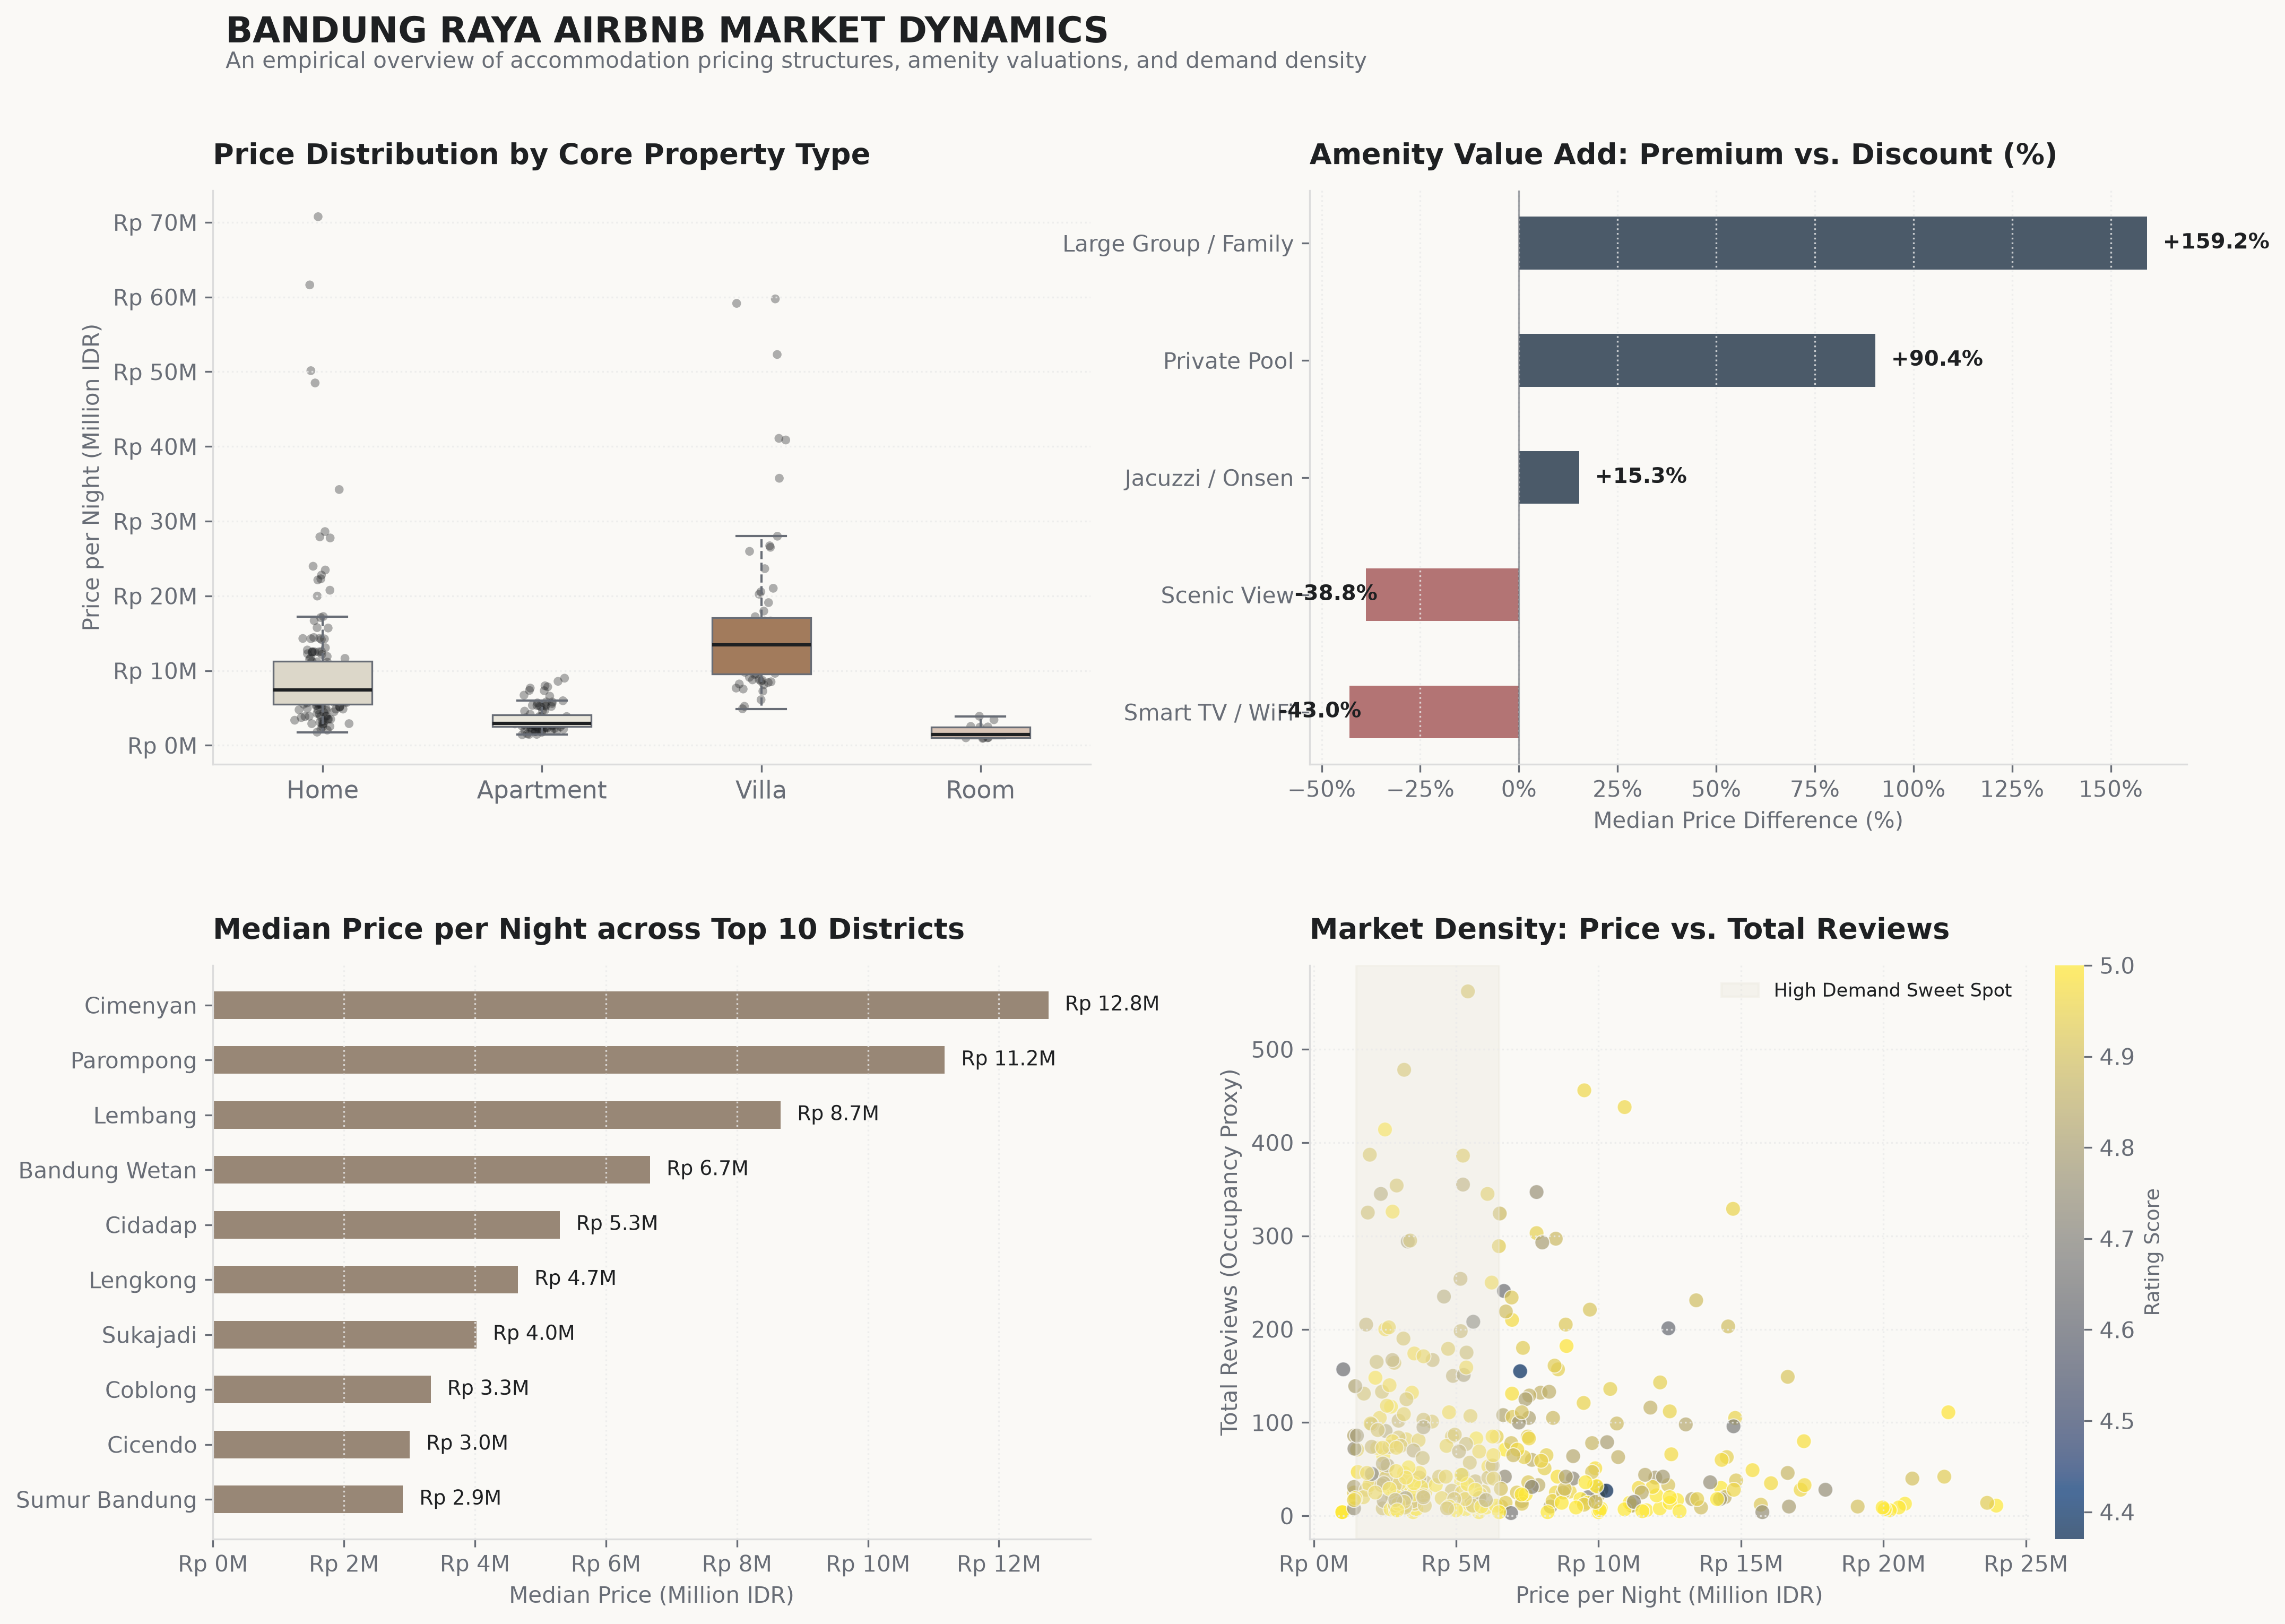

In [5]:
BG_COLOR = "#FAF9F6"
TEXT_MAIN = "#1E2022"
TEXT_MUTED = "#686D76"
ACCENT_NAVY = "#2C3E50"
ACCENT_TAUPE = "#8D7B68"
ACCENT_MUTED_RED = "#A75D5D"
GRID_COLOR = "#EAEAEA"

plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'figure.facecolor': BG_COLOR,
    'axes.facecolor': BG_COLOR,
    'text.color': TEXT_MAIN,
    'axes.labelcolor': TEXT_MAIN,
    'xtick.color': TEXT_MUTED,
    'ytick.color': TEXT_MUTED,
    'axes.edgecolor': '#DCDCDC',
    'axes.linewidth': 0.8
})

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=300)
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# --- CHART 1: Price Distribution (Boxplot + Jitter Points) ---
ax1 = axes[0, 0]
top_types = ['Home', 'Apartment', 'Villa', 'Room']
df_p1 = bdf[bdf['property_type'].isin(top_types)].copy()
df_p1['price_mil'] = df_p1['price_idr'] / 1e6

box_data = [df_p1[df_p1['property_type'] == t]['price_mil'] for t in top_types]
bp = ax1.boxplot(box_data, patch_artist=True, widths=0.45, showfliers=False,
                 medianprops=dict(color=TEXT_MAIN, linewidth=1.5),
                 whiskerprops=dict(color=TEXT_MUTED, linewidth=1.0, linestyle='--'),
                 capprops=dict(color=TEXT_MUTED, linewidth=1.0))

colors_box = ['#DCD7C9', '#EAE7DC', '#A27B5C', '#D8C4B6']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_edgecolor(TEXT_MUTED)
    patch.set_linewidth(0.8)

for i, t in enumerate(top_types):
    y = df_p1[df_p1['property_type'] == t]['price_mil']
    x = np.random.normal(i + 1, 0.05, size=len(y))
    ax1.scatter(x, y, alpha=0.35, color=TEXT_MAIN, s=16, edgecolors='none')

ax1.set_xticklabels(top_types, fontsize=11, fontweight='medium')
ax1.set_title('Price Distribution by Core Property Type', fontsize=13, fontweight='bold', pad=12, loc='left', color=TEXT_MAIN)
ax1.set_ylabel('Price per Night (Million IDR)', fontsize=10, color=TEXT_MUTED)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('Rp %.0fM'))
ax1.grid(axis='y', linestyle=':', color=GRID_COLOR, alpha=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- CHART 2: Amenity Value Add (%) ---
ax2 = axes[0, 1]
amenity_stats = []
for label, pattern in amenities.items():
    w = bdf[bdf[label] == True]['price_idr'].median()
    wo = bdf[bdf[label] == False]['price_idr'].median()
    diff_pct = 100.0 * (w - wo) / wo
    amenity_stats.append({'Amenity': label, 'Premium_Pct': diff_pct})

df_am = pd.DataFrame(amenity_stats).sort_values('Premium_Pct', ascending=True)
bar_colors = [ACCENT_NAVY if x >= 0 else ACCENT_MUTED_RED for x in df_am['Premium_Pct']]

bars = ax2.barh(df_am['Amenity'], df_am['Premium_Pct'], color=bar_colors, height=0.45, alpha=0.85)
ax2.axvline(0, color=TEXT_MUTED, linestyle='-', linewidth=0.8, alpha=0.6)
ax2.set_title('Amenity Value Add: Premium vs. Discount (%)', fontsize=13, fontweight='bold', pad=12, loc='left', color=TEXT_MAIN)
ax2.set_xlabel('Median Price Difference (%)', fontsize=10, color=TEXT_MUTED)
ax2.xaxis.set_major_formatter(ticker.PercentFormatter())
ax2.grid(axis='x', linestyle=':', color=GRID_COLOR, alpha=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar in bars:
    w = bar.get_width()
    offset = 4 if w >= 0 else -18
    ax2.text(w + offset, bar.get_y() + bar.get_height()/2, f"{w:+.1f}%", va='center', fontsize=9.5, fontweight='bold', color=TEXT_MAIN)

# --- CHART 3: Top 10 Districts Median Price ---
ax3 = axes[1, 0]
top_10_dist = bdf['district'].value_counts().head(10).index
dist_data = bdf[bdf['district'].isin(top_10_dist)].groupby('district')['price_idr'].median().sort_values(ascending=True) / 1e6

bars3 = ax3.barh(dist_data.index, dist_data.values, color=ACCENT_TAUPE, height=0.5, alpha=0.9)
ax3.set_title('Median Price per Night across Top 10 Districts', fontsize=13, fontweight='bold', pad=12, loc='left', color=TEXT_MAIN)
ax3.set_xlabel('Median Price (Million IDR)', fontsize=10, color=TEXT_MUTED)
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('Rp %.0fM'))
ax3.grid(axis='x', linestyle=':', color=GRID_COLOR, alpha=0.8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for bar in bars3:
    w = bar.get_width()
    ax3.text(w + 0.25, bar.get_y() + bar.get_height()/2, f"Rp {w:.1f}M", va='center', fontsize=9, fontweight='medium', color=TEXT_MAIN)

# --- CHART 4: Market Density: Price vs. Reviews ---
ax4 = axes[1, 1]
scat_data = bdf.dropna(subset=['rating_clean']).copy()
scat_data['price_mil'] = scat_data['price_idr'] / 1e6
scat_subset = scat_data[scat_data['price_mil'] <= 25]

sc = ax4.scatter(scat_subset['price_mil'], scat_subset['jumlah_review'],
                 c=scat_subset['rating_clean'], cmap='cividis',
                 s=45, alpha=0.7, edgecolors='white', linewidth=0.5)

ax4.set_title('Market Density: Price vs. Total Reviews', fontsize=13, fontweight='bold', pad=12, loc='left', color=TEXT_MAIN)
ax4.set_xlabel('Price per Night (Million IDR)', fontsize=10, color=TEXT_MUTED)
ax4.set_ylabel('Total Reviews (Occupancy Proxy)', fontsize=10, color=TEXT_MUTED)
ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('Rp %.0fM'))
ax4.grid(True, linestyle=':', color=GRID_COLOR, alpha=0.8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

ax4.axvspan(1.5, 6.5, color='#EAE7DC', alpha=0.35, label='High Demand Sweet Spot')
cbar = plt.colorbar(sc, ax=ax4, pad=0.03, aspect=20)
cbar.set_label('Rating Score', fontsize=9, color=TEXT_MUTED)
cbar.outline.set_visible(False)
ax4.legend(frameon=False, loc='upper right', fontsize=8.5)

# Overall Header & Subtitle
plt.suptitle('BANDUNG RAYA AIRBNB MARKET DYNAMICS', fontsize=16, fontweight='bold', color=TEXT_MAIN, y=0.98, x=0.13, ha='left')
fig.text(0.13, 0.95, 'An empirical overview of accommodation pricing structures, amenity valuations, and demand density', fontsize=10, color=TEXT_MUTED, ha='left')

plt.savefig('airbnb_bandung_minimalist.png', dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()